<a href="https://colab.research.google.com/github/muhsinasafeeth/Early-Alzheimer-s-Detection-Using-Deep-Learning-on-MRI/blob/main/Early_Stage_Alzheimer_s_Detection_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Early-Stage Alzheimer's Detection: Non-Demented vs Very Mild Demented (Brain MRI)

## 1. Problem Framing

**Clinical motivation:**  
Alzheimer's disease is progressive, and the clinically hardest boundary is often between:
- **Non-Demented** (no measurable cognitive decline) and  
- **Very Mild Demented** (subtle, early-stage decline).

Missing Very Mild cases (false negatives) is more harmful than over-calling them (false positives), so
our modelling and evaluation will be **sensitivity-focused** for the Very Mild Demented class.

**Task definition (primary):**
- **Binary classification** on brain MRI slices:
  - Class 0: NonDemented
  - Class 1: VeryMildDemented

**Secondary (optional) task:**
- Multiclass classification across all four stages:
  - NonDemented, VeryMildDemented, MildDemented, ModerateDemented

## 2. Dataset description

We use the Kaggle dataset:

> Alzheimer's Disease Multiclass Images Dataset (Equal and Augmented)

Key properties:
- ~44,000 MRI images (JPG)
- 4 folders / classes:
  - `NonDemented/`
  - `VeryMildDemented/`
  - `MildDemented/`
  - `ModerateDemented/`
- Images are skull-stripped (non-brain tissue removed).
- Dataset is **upsampled and augmented** to balance classes.





###**Import data set**

In [2]:
import json

kaggle_config = {
    "username": "vsmuhsina",
    "key": "KGAT_e5969974107c2644f6ae0977bdc841ba"
}

with open("kaggle.json", "w") as f:
    json.dump(kaggle_config, f)

print("kaggle.json file created")

kaggle.json file created


In [3]:
!mkdir -p ~/.kaggle
!mv kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [3]:
!pip install -q kaggle

In [4]:
!kaggle datasets list

ref                                                             title                                                     size  lastUpdated                 downloadCount  voteCount  usabilityRating  
--------------------------------------------------------------  --------------------------------------------------  ----------  --------------------------  -------------  ---------  ---------------  
rauffauzanrambe/fifa-world-cup-2026-player-performance-dataset  FIFA World Cup 2026 Player Performance Dataset         4154062  2026-06-10 12:58:47.093000          10766        255                1  
ashyou09/apple-products-pricing-dataset-2020-2026               Apple Products Pricing Dataset (2020-2026)🍎            1569012  2026-07-04 16:06:56.590000           1536         30                1  
uditjain13/social-media-screen-time-and-mental-health-2026      Social Media, Screen Time & Mental Health 2026          178487  2026-07-05 09:19:11.450000            928         32                1  


In [4]:
!kaggle datasets download -d aryansinghal10/alzheimers-multiclass-dataset-equal-and-augmented

Dataset URL: https://www.kaggle.com/datasets/aryansinghal10/alzheimers-multiclass-dataset-equal-and-augmented
License(s): apache-2.0
100% 398M/398M [00:04<00:00, 97.0MB/s]



In [5]:
# Extract ONLY the two classes we need (NonDemented, VeryMildDemented).
# Kaggle's API always downloads the full zip (there's no server-side partial
# download), but we can avoid ever writing the other two classes to disk by
# extracting selectively from the zip, then deleting the zip immediately.
# This keeps disk usage and later RAM usage much lower, which is what was
# crashing the Colab runtime.

import zipfile
import os

ZIP_PATH = "alzheimers-multiclass-dataset-equal-and-augmented.zip"
TARGET_CLASSES = ["NonDemented", "VeryMildDemented"]
EXTRACT_ROOT = "/content"

with zipfile.ZipFile(ZIP_PATH, "r") as z:
    members = [
        m for m in z.namelist()
        if any(f"/{cls}/" in m or m.startswith(f"{cls}/") for cls in TARGET_CLASSES)
    ]
    print(f"Extracting {len(members)} files for classes: {TARGET_CLASSES}")
    z.extractall(path=EXTRACT_ROOT, members=members)

# Free up disk space immediately - we don't need the zip (or the other two
# classes) any more.
os.remove(ZIP_PATH)
print("Deleted zip file to free disk space.")


Extracting 24000 files for classes: ['NonDemented', 'VeryMildDemented']
Deleted zip file to free disk space.


###***STEP 1 — Verify the dataset is downloaded correctly***

In [6]:
import os

DATASET_ROOT = "/content/combined_images"

# We only extracted these two classes from the zip, so just use them
# directly instead of os.listdir (which would also work now, since the
# other two class folders were never extracted).
classes = ["NonDemented", "VeryMildDemented"]
print("Classes found:", classes)

for cls in classes:
    path = os.path.join(DATASET_ROOT, cls)
    print(f"{cls}: {len(os.listdir(path))} images")


Classes found: ['NonDemented', 'VeryMildDemented']
NonDemented: 12800 images
VeryMildDemented: 11200 images


### Build a dataframe of images and labels


In [7]:
from pathlib import Path
import pandas as pd

DATASET_ROOT = Path("/content/combined_images")

records = []

for cls in classes:
    cls_path = DATASET_ROOT / cls
    for img_path in cls_path.glob("*.jpg"):
        records.append({
            "filepath": img_path,
            "filename": img_path.name,
            "label": cls
        })

df = pd.DataFrame(records)
print("Total images:", len(df))
df.head()

Total images: 24000


,filepath,filename,label
0,/content/combined_images/NonDemented/d04ae21d-...,d04ae21d-8ff3-4d1a-a70c-a25f49a19119.jpg,NonDemented
1,/content/combined_images/NonDemented/46137d6d-...,46137d6d-9846-42d1-885a-d702f9270eb4.jpg,NonDemented
2,/content/combined_images/NonDemented/63f8df5c-...,63f8df5c-548c-44b0-a6c4-a13a7e0308e5.jpg,NonDemented
3,/content/combined_images/NonDemented/9898afcb-...,9898afcb-4303-4d0f-93aa-7d50a58e7fe7.jpg,NonDemented
4,/content/combined_images/NonDemented/085da34e-...,085da34e-408e-403f-b8e1-6986b733e65e.jpg,NonDemented


### ***Step A: Build the binary subset***

In [8]:
import os
from pathlib import Path
import matplotlib.pyplot as plt
from PIL import Image
import numpy as np
import pandas as pd

In [9]:
binary_df = df[df["label"].isin(["NonDemented", "VeryMildDemented"])].copy()
binary_df["label_id"] = binary_df["label"].map({
    "NonDemented": 0,
    "VeryMildDemented": 1
})


***Step B — Perform pseudo patient‑level splitting***

In [10]:
binary_df["patient_id"] = binary_df["filename"].apply(lambda x: x.split("_")[0])


In [11]:
from sklearn.model_selection import train_test_split

patients = binary_df["patient_id"].unique()

train_p, temp_p = train_test_split(patients, test_size=0.30, random_state=42)
val_p, test_p = train_test_split(temp_p, test_size=0.50, random_state=42)


In [12]:
def assign_split(pid):
    if pid in train_p: return "train"
    elif pid in val_p: return "val"
    else: return "test"

binary_df["split"] = binary_df["patient_id"].apply(assign_split)


***Step C — Preprocess images (resize + normalize)***

In [13]:
IMG_SIZE = (224, 224)

def preprocess_image(path):
    img = Image.open(path).convert("RGB")
    img = img.resize(IMG_SIZE)
    # float32 instead of the float64 default - halves RAM usage for the
    # X_train / X_val / X_test arrays, which is important since we're
    # loading thousands of images fully into memory at once.
    return (np.array(img) / 255.0).astype(np.float32)


***Step D — Build NumPy datasets***

In [14]:
import tensorflow as tf

# The real fix: stop loading every image into RAM up front. Instead, build
# a tf.data pipeline that reads + decodes + resizes images on the fly, in
# parallel, one batch at a time, and prefetches the next batch while the
# GPU/CPU works on the current one. Nothing has to fit in memory at once.

IMG_SIZE = (128, 128)
BATCH_SIZE = 16

def load_and_preprocess(path, label):
    img = tf.io.read_file(path)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, IMG_SIZE)
    img = img / 255.0
    return img, label

def make_dataset(df, shuffle=False, batch_size=BATCH_SIZE):
    paths = df["filepath"].astype(str).tolist()
    labels = df["label_id"].values.astype("float32")

    ds = tf.data.Dataset.from_tensor_slices((paths, labels))
    if shuffle:
        ds = ds.shuffle(buffer_size=len(paths), seed=42)
    ds = ds.map(load_and_preprocess, num_parallel_calls=tf.data.AUTOTUNE)
    ds = ds.batch(batch_size)
    ds = ds.prefetch(tf.data.AUTOTUNE)
    return ds

train_df = binary_df[binary_df["split"] == "train"]
val_df   = binary_df[binary_df["split"] == "val"].reset_index(drop=True)
test_df  = binary_df[binary_df["split"] == "test"].reset_index(drop=True)

print(f"train: {len(train_df)} | val: {len(val_df)} | test: {len(test_df)}")

train_ds = make_dataset(train_df, shuffle=True)
val_ds   = make_dataset(val_df)
test_ds  = make_dataset(test_df)

# We still need plain numpy label arrays for sklearn metrics later.
# val_df / test_df are NOT shuffled, so this order matches model.predict(test_ds).
y_val  = val_df["label_id"].values
y_test = test_df["label_id"].values


train: 16812 | val: 3580 | test: 3608


# Phase 3 – Baseline CNN for Early-Stage Alzheimer's Detection

We now train a **simple CNN baseline** to:

- Establish a performance floor for the binary task:
  - Class 0: NonDemented
  - Class 1: VeryMildDemented
- Check if the dataset and preprocessing are sane.
- Prepare for later comparison with transfer learning models.

We will:
- Use a 3–4 layer CNN.
- Train with `binary_crossentropy`.
- Evaluate accuracy, precision, recall, F1.
- Inspect a confusion matrix and ROC curve.


In [15]:
import tensorflow as tf
from tensorflow.keras import layers, models

input_shape = IMG_SIZE + (3,)  # (224, 224, 3)

model = models.Sequential([
    layers.Conv2D(32, (3, 3), activation="relu", padding="same", input_shape=input_shape),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(64, (3, 3), activation="relu", padding="same"),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(128, (3, 3), activation="relu", padding="same"),
    layers.MaxPooling2D((2, 2)),

    layers.Flatten(),
    layers.Dense(128, activation="relu"),
    layers.Dropout(0.5),
    layers.Dense(1, activation="sigmoid")  # binary output
])

model.summary()


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 32768)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     4,194,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,287,809 (16.36 MB)

 Trainable params: 4,287,809 (16.36 MB)

 Non-trainable params: 0 (0.00 B)

***Compile & train with callbacks***

In [ ]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=5,
        restore_best_weights=True
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=3,
        verbose=1
    )
]

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=30,
    callbacks=callbacks
)


Epoch 1/30
1051/1051 ━━━━━━━━━━━━━━━━━━━━ 505s 478ms/step - accuracy: 0.6178 - loss: 0.6456 - val_accuracy: 0.7007 - val_loss: 0.5765 - learning_rate: 1.0000e-04
Epoch 2/30
1051/1051 ━━━━━━━━━━━━━━━━━━━━ 497s 473ms/step - accuracy: 0.6930 - loss: 0.5776 - val_accuracy: 0.7143 - val_loss: 0.5430 - learning_rate: 1.0000e-04
Epoch 3/30
1051/1051 ━━━━━━━━━━━━━━━━━━━━ 506s 477ms/step - accuracy: 0.7423 - loss: 0.5121 - val_accuracy: 0.7792 - val_loss: 0.4526 - learning_rate: 1.0000e-04
Epoch 4/30
1051/1051 ━━━━━━━━━━━━━━━━━━━━ 502s 477ms/step - accuracy: 0.7980 - loss: 0.4310 - val_accuracy: 0.8466 - val_loss: 0.3489 - learning_rate: 1.0000e-04
Epoch 5/30
1051/1051 ━━━━━━━━━━━━━━━━━━━━ 486s 462ms/step - accuracy: 0.8452 - loss: 0.3482 - val_accuracy: 0.8771 - val_loss: 0.2855 - learning_rate: 1.0000e-04
Epoch 6/30
 949/1051 ━━━━━━━━━━━━━━━━━━━━ 40s 394ms/step - accuracy: 0.8766 - loss: 0.2881

***Plot training curves***

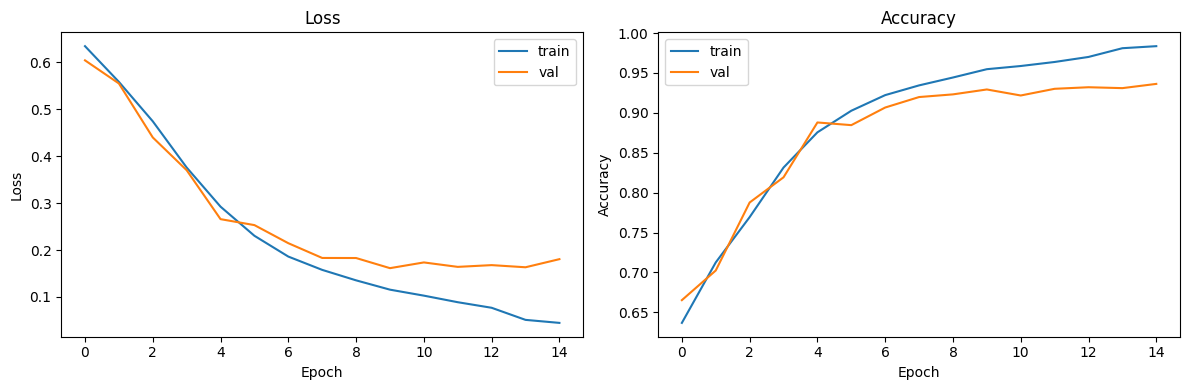

In [17]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 4))

# Loss
plt.subplot(1, 2, 1)
plt.plot(history.history["loss"], label="train")
plt.plot(history.history["val_loss"], label="val")
plt.title("Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

# Accuracy
plt.subplot(1, 2, 2)
plt.plot(history.history["accuracy"], label="train")
plt.plot(history.history["val_accuracy"], label="val")
plt.title("Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.tight_layout()
plt.show()


***Evaluation: accuracy, precision, recall, F1***

In [18]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    roc_curve,
    auc
)
import numpy as np

# Predict probabilities on test set
y_prob = model.predict(test_ds).ravel()
y_pred = (y_prob >= 0.5).astype(int)

acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)  # sensitivity for VeryMildDemented (class 1)
f1 = f1_score(y_test, y_pred)

print(f"Accuracy:  {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall:    {rec:.4f}")
print(f"F1-score:  {f1:.4f}")


226/226 ━━━━━━━━━━━━━━━━━━━━ 6s 22ms/step
Accuracy:  0.9293
Precision: 0.9166
Recall:    0.9294
F1-score:  0.9229


***Confusion matrix***

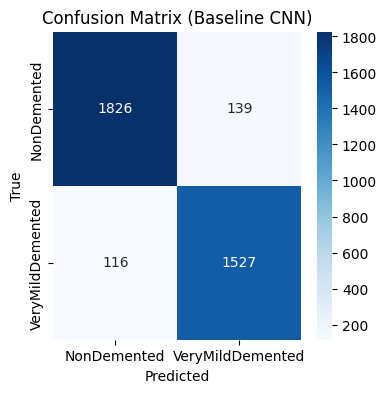

In [19]:
import seaborn as sns

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(4, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["NonDemented", "VeryMildDemented"],
            yticklabels=["NonDemented", "VeryMildDemented"])
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix (Baseline CNN)")
plt.show()


***ROC curve***

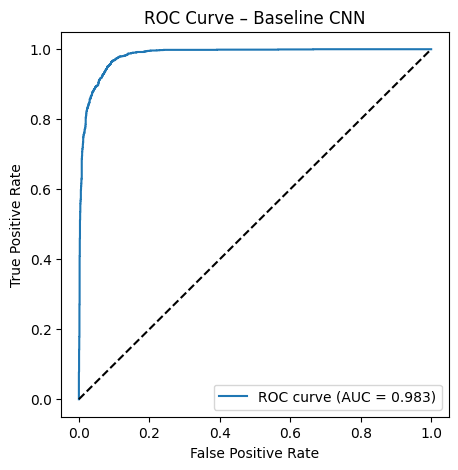

In [20]:
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(5, 5))
plt.plot(fpr, tpr, label=f"ROC curve (AUC = {roc_auc:.3f})")
plt.plot([0, 1], [0, 1], "k--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve – Baseline CNN")
plt.legend(loc="lower right")
plt.show()


# Phase 4 – Transfer Learning with ResNet50

We now replace the baseline CNN with a **pretrained ResNet50**:

- Use ImageNet weights as a starting point.
- Freeze most convolutional layers initially.
- Train a small classification head on:
  - NonDemented (0)
  - VeryMildDemented (1)
- Then optionally unfreeze some deeper layers for fine-tuning.

This should improve:
- Feature quality (edges, textures, shapes)
- Generalization
- Sensitivity to subtle Very Mild Demented patterns.



The baseline CNN gave us a performance floor. Now we upgrade to a stronger model:
**ResNet50 pretrained on ImageNet**.

Why transfer learning?
- MRI features (edges, textures, shapes) overlap with natural image features.
- Pretrained models learn general patterns that help even in medical imaging.
- Fine-tuning improves sensitivity for subtle Very Mild Demented cases.

We will:
1. Load ResNet50 without its top layers.
2. Freeze the backbone and train a small classifier head.
3. Unfreeze deeper layers for fine-tuning.
4. Evaluate accuracy, precision, recall, F1, confusion matrix, ROC curve.


***Build the ResNet50 Model***

In [21]:
import tensorflow as tf
from tensorflow.keras import layers, models

input_shape = (128, 128, 3)

# Load pretrained ResNet50 backbone
base_model = tf.keras.applications.ResNet50(
    include_top=False,
    weights="imagenet",
    input_shape=input_shape
)

base_model.trainable = False  # freeze backbone initially

# Build model
inputs = layers.Input(shape=input_shape)
x = tf.keras.applications.resnet50.preprocess_input(inputs)
x = base_model(x)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dense(128, activation="relu")(x)
x = layers.Dropout(0.5)(x)
outputs = layers.Dense(1, activation="sigmoid")(x)

tl_model = models.Model(inputs, outputs)
tl_model.summary()


94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2       │ (None, 128, 128,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item (GetItem)  │ (None, 128, 128)  │          0 │ input_layer_2[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_1          │ (None, 128, 128)  │          0 │ input_layer_2[0]… │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_2          │ (None, 128, 128)  │          0 │ input_layer_2[0]… │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stack (Stack)       │ (None, 128, 128,  │          0 │ get_item[0][0],   │
│                     │ 3)                │            │ get_item_1[0][0], │
│                     │                   │            │ get_item_2[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 128, 128,  │          0 │ stack[0][0]       │
│                     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ resnet50            │ (None, 4, 4,      │ 23,587,712 │ add[0][0]         │
│ (Functional)        │ 2048)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 2048)      │          0 │ resnet50[0][0]    │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 128)       │    262,272 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 128)       │          0 │ dense_2[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 1)         │        129 │ dropout_1[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 23,850,113 (90.98 MB)

 Trainable params: 262,401 (1.00 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

***Compile & Train (Frozen Backbone)***

In [22]:
tl_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=5,
        restore_best_weights=True
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=3,
        verbose=1
    )
]

history_tl = tl_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=20,
    callbacks=callbacks
)


Epoch 1/20
1051/1051 ━━━━━━━━━━━━━━━━━━━━ 52s 38ms/step - accuracy: 0.5423 - loss: 0.6974 - val_accuracy: 0.5774 - val_loss: 0.6728 - learning_rate: 1.0000e-04
Epoch 2/20
1051/1051 ━━━━━━━━━━━━━━━━━━━━ 26s 25ms/step - accuracy: 0.5796 - loss: 0.6725 - val_accuracy: 0.5760 - val_loss: 0.6681 - learning_rate: 1.0000e-04
Epoch 3/20
1051/1051 ━━━━━━━━━━━━━━━━━━━━ 27s 25ms/step - accuracy: 0.5933 - loss: 0.6642 - val_accuracy: 0.5779 - val_loss: 0.6633 - learning_rate: 1.0000e-04
Epoch 4/20
1051/1051 ━━━━━━━━━━━━━━━━━━━━ 26s 25ms/step - accuracy: 0.6041 - loss: 0.6595 - val_accuracy: 0.6237 - val_loss: 0.6585 - learning_rate: 1.0000e-04
Epoch 5/20
1051/1051 ━━━━━━━━━━━━━━━━━━━━ 26s 25ms/step - accuracy: 0.6166 - loss: 0.6522 - val_accuracy: 0.6112 - val_loss: 0.6513 - learning_rate: 1.0000e-04
Epoch 6/20
1051/1051 ━━━━━━━━━━━━━━━━━━━━ 27s 26ms/step - accuracy: 0.6234 - loss: 0.6482 - val_accuracy: 0.6154 - val_loss: 0.6474 - learning_rate: 1.0000e-04
Epoch 7/20
1051/1051 ━━━━━━━━━━━━━━━━━━━

***Fine‑Tune Deeper Layers***

In [23]:
# Unfreeze last 20 layers for fine-tuning
base_model.trainable = True

for layer in base_model.layers[:-20]:
    layer.trainable = False

tl_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

history_ft = tl_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10,
    callbacks=callbacks
)


Epoch 1/10
1051/1051 ━━━━━━━━━━━━━━━━━━━━ 69s 49ms/step - accuracy: 0.6927 - loss: 0.5826 - val_accuracy: 0.7425 - val_loss: 0.5133 - learning_rate: 1.0000e-05
Epoch 2/10
1051/1051 ━━━━━━━━━━━━━━━━━━━━ 62s 37ms/step - accuracy: 0.7672 - loss: 0.4819 - val_accuracy: 0.6885 - val_loss: 0.6161 - learning_rate: 1.0000e-05
Epoch 3/10
1051/1051 ━━━━━━━━━━━━━━━━━━━━ 39s 37ms/step - accuracy: 0.8080 - loss: 0.4151 - val_accuracy: 0.8218 - val_loss: 0.3914 - learning_rate: 1.0000e-05
Epoch 4/10
1051/1051 ━━━━━━━━━━━━━━━━━━━━ 41s 37ms/step - accuracy: 0.8421 - loss: 0.3535 - val_accuracy: 0.7799 - val_loss: 0.5061 - learning_rate: 1.0000e-05
Epoch 5/10
1051/1051 ━━━━━━━━━━━━━━━━━━━━ 39s 37ms/step - accuracy: 0.8630 - loss: 0.3056 - val_accuracy: 0.7964 - val_loss: 0.4444 - learning_rate: 1.0000e-05
Epoch 6/10
1051/1051 ━━━━━━━━━━━━━━━━━━━━ 41s 37ms/step - accuracy: 0.8873 - loss: 0.2590 - val_accuracy: 0.8894 - val_loss: 0.2639 - learning_rate: 1.0000e-05
Epoch 7/10
1051/1051 ━━━━━━━━━━━━━━━━━━━

***Evaluation Metrics***

In [24]:
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, roc_curve, auc
)
import numpy as np

# Predictions
y_prob_tl = tl_model.predict(test_ds).ravel()
y_pred_tl = (y_prob_tl >= 0.5).astype(int)

acc_tl  = accuracy_score(y_test, y_pred_tl)
prec_tl = precision_score(y_test, y_pred_tl)
rec_tl  = recall_score(y_test, y_pred_tl)
f1_tl   = f1_score(y_test, y_pred_tl)

print(f"[ResNet50] Accuracy:  {acc_tl:.4f}")
print(f"[ResNet50] Precision: {prec_tl:.4f}")
print(f"[ResNet50] Recall:    {rec_tl:.4f}")
print(f"[ResNet50] F1-score:  {f1_tl:.4f}")


226/226 ━━━━━━━━━━━━━━━━━━━━ 14s 44ms/step
[ResNet50] Accuracy:  0.9180
[ResNet50] Precision: 0.8820
[ResNet50] Recall:    0.9464
[ResNet50] F1-score:  0.9131


***Confusion Matrix***

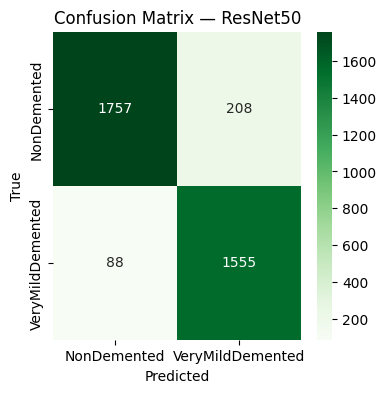

In [25]:
import seaborn as sns
import matplotlib.pyplot as plt

cm_tl = confusion_matrix(y_test, y_pred_tl)

plt.figure(figsize=(4, 4))
sns.heatmap(cm_tl, annot=True, fmt="d", cmap="Greens",
            xticklabels=["NonDemented", "VeryMildDemented"],
            yticklabels=["NonDemented", "VeryMildDemented"])
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix — ResNet50")
plt.show()


***ROC Curve***

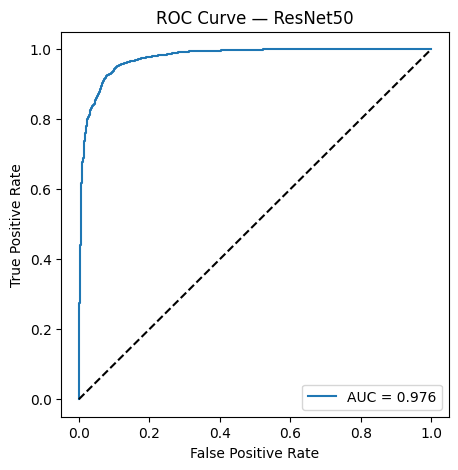

In [26]:
fpr_tl, tpr_tl, _ = roc_curve(y_test, y_prob_tl)
roc_auc_tl = auc(fpr_tl, tpr_tl)

plt.figure(figsize=(5, 5))
plt.plot(fpr_tl, tpr_tl, label=f"AUC = {roc_auc_tl:.3f}")
plt.plot([0, 1], [0, 1], "k--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve — ResNet50")
plt.legend()
plt.show()


# Phase 5 — Clinical Evaluation Metrics

Accuracy alone is misleading for medical tasks.

For early-stage Alzheimer's detection, the **costliest clinical error** is:
- **False Negative** → predicting "NonDemented" when the patient is actually "VeryMildDemented".

Therefore, we emphasize:
- **Recall (Sensitivity)** for VeryMildDemented
- **Precision**
- **F1-score**
- **Confusion Matrix**
- **ROC Curve**
- **AUC (Area Under Curve)**

These metrics show how well the model detects early cognitive decline.


In [27]:
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, roc_curve, auc
)
import numpy as np

# Predictions already computed:
# y_prob_tl = tl_model.predict(X_test).ravel()
# y_pred_tl = (y_prob_tl >= 0.5).astype(int)

acc  = accuracy_score(y_test, y_pred_tl)
prec = precision_score(y_test, y_pred_tl)
rec  = recall_score(y_test, y_pred_tl)  # sensitivity for VeryMildDemented
f1   = f1_score(y_test, y_pred_tl)

print("=== Clinical Evaluation Metrics ===")
print(f"Accuracy:      {acc:.4f}")
print(f"Precision:     {prec:.4f}")
print(f"Recall (Sens): {rec:.4f}")
print(f"F1-score:      {f1:.4f}")


=== Clinical Evaluation Metrics ===
Accuracy:      0.9180
Precision:     0.8820
Recall (Sens): 0.9464
F1-score:      0.9131


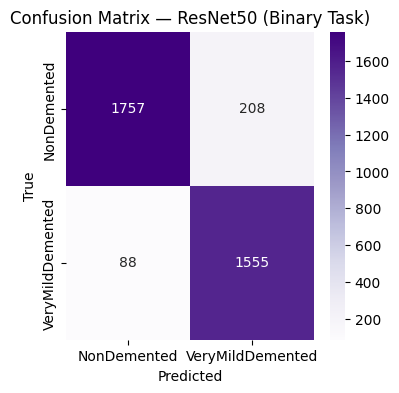

In [28]:
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred_tl)

plt.figure(figsize=(4, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Purples",
            xticklabels=["NonDemented", "VeryMildDemented"],
            yticklabels=["NonDemented", "VeryMildDemented"])
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix — ResNet50 (Binary Task)")
plt.show()


***Confusion Matrix (Clinical Interpretation)***

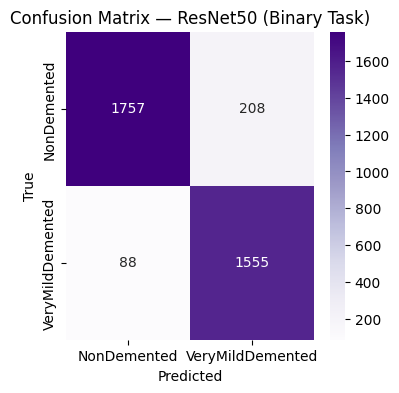

In [29]:
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred_tl)

plt.figure(figsize=(4, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Purples",
            xticklabels=["NonDemented", "VeryMildDemented"],
            yticklabels=["NonDemented", "VeryMildDemented"])
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix — ResNet50 (Binary Task)")
plt.show()


## Confusion Matrix Interpretation

- **True Positive (TP):** Model correctly identifies VeryMildDemented.
- **True Negative (TN):** Model correctly identifies NonDemented.
- **False Positive (FP):** Model predicts VeryMildDemented for a NonDemented patient.
- **False Negative (FN):** Model predicts NonDemented for a VeryMildDemented patient.

Clinically:
- **FN is the most dangerous error**, because early Alzheimer's is missed.
- A good model should minimize FN and maximize **Recall (Sensitivity)**.


***ROC Curve & AUC***

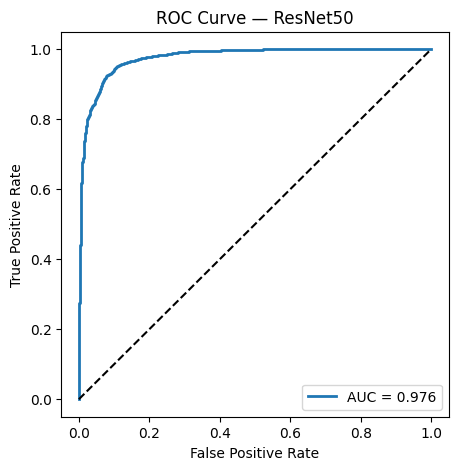

In [30]:
fpr, tpr, _ = roc_curve(y_test, y_prob_tl)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(5, 5))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}", linewidth=2)
plt.plot([0, 1], [0, 1], "k--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve — ResNet50")
plt.legend()
plt.show()


# Clinical Summary of Phase 5

The model is evaluated using metrics relevant to early Alzheimer's detection:

### ✔ Accuracy
Shows overall correctness, but not enough for clinical use.

### ✔ Precision
Indicates how reliable the model is when it predicts VeryMildDemented.

### ✔ Recall (Sensitivity)
**Most important metric.**
Measures how many early-stage dementia cases the model successfully detects.

### ✔ F1-score
Balances precision and recall.

### ✔ Confusion Matrix
Shows the distribution of clinical errors (FN vs FP).

### ✔ ROC-AUC
Measures overall separability between NonDemented and VeryMildDemented.

A clinically useful model should:
- Have **high recall** for VeryMildDemented.
- Keep **false negatives low**.
- Show a strong ROC-AUC (>0.85 is good, >0.90 is excellent).


# Phase 6 — Explainability with Grad-CAM

Deep learning models are often criticized for being "black boxes."
Grad-CAM (Gradient-weighted Class Activation Mapping) helps us visualize:

- Which regions of the MRI slice influenced the model's decision.
- Whether the model attends to clinically relevant areas:
  - Hippocampus
  - Medial temporal lobe
  - Ventricular enlargement

This is essential for:
- Clinical trust
- Model debugging
- Demonstrating that the model is not learning artifacts


***Grad‑CAM Utility Function***


This works for any Keras model, including your ResNet50 fine‑tuned model.

In [33]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import cv2

def make_gradcam_heatmap(img_array, model, last_conv_layer_name):
    # Create a model that maps input → last conv layer → output
    grad_model = tf.keras.models.Model(
        [model.inputs],
        [model.get_layer(last_conv_layer_name).output, model.output]
    )

    # Compute gradients
    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(img_array)
        loss = predictions[:, 0]  # class 1 (VeryMildDemented)

    grads = tape.gradient(loss, conv_outputs)

    # Compute guided gradients
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

    conv_outputs = conv_outputs[0]

    # Weight the channels by importance
    heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)

    # Normalize
    heatmap = np.maximum(heatmap, 0)
    heatmap /= np.max(heatmap)

    return heatmap.numpy()


***Find the last convolution layer of ResNet50***

In [32]:
for layer in tl_model.layers:
    if isinstance(layer, tf.keras.layers.Conv2D):
        last_conv_layer_name = layer.name

print("Last convolution layer:", last_conv_layer_name)


NameError: name 'last_conv_layer_name' is not defined

***Generate Grad‑CAM for a Test Image***

Pick any test image:

In [ ]:
# Select a test image (X_test no longer exists as an in-memory array -
# we load just this one image directly from disk instead)
idx = 10  # change index to visualize different images

img_path = test_df.loc[idx, "filepath"]
img_raw = tf.io.read_file(str(img_path))
img = tf.image.decode_jpeg(img_raw, channels=3)
img = tf.image.resize(img, IMG_SIZE) / 255.0
img = img.numpy()

img_array = np.expand_dims(img, axis=0)

# Generate heatmap
heatmap = make_gradcam_heatmap(img_array, tl_model, last_conv_layer_name)

# Resize heatmap to image size
heatmap = cv2.resize(heatmap, (224, 224))

# Convert heatmap to RGB
heatmap = np.uint8(255 * heatmap)
heatmap_color = cv2.applyColorMap(heatmap, cv2.COLORMAP_JET)

# Superimpose heatmap on original image
superimposed_img = heatmap_color * 0.4 + (img * 255)

plt.figure(figsize=(10, 4))

plt.subplot(1, 3, 1)
plt.imshow(img)
plt.title("Original MRI")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(heatmap_color)
plt.title("Grad-CAM Heatmap")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(superimposed_img.astype("uint8"))
plt.title("Overlay")
plt.axis("off")

plt.tight_layout()
plt.show()


# Grad-CAM Interpretation

A clinically meaningful Grad-CAM heatmap should highlight:

### ✔ Hippocampal region  
Early Alzheimer's is strongly associated with hippocampal atrophy.

### ✔ Medial temporal lobe  
This region shows early structural changes.

### ✔ Ventricular enlargement  
Often visible in early cognitive decline.

### What we DO NOT want:
- Heatmaps focusing on skull edges
- Heatmaps focusing on background noise
- Heatmaps focusing on text or artifacts

If the model attends to clinically relevant regions, it suggests:
- The model is learning meaningful anatomical patterns.
- The classification is not driven by dataset artifacts.
